11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Entrenando MLP...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9248 - loss: 0.2563 - val_accuracy: 0.9698 - val_loss: 0.1130
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9671 - loss: 0.1079 - val_accuracy: 0.9727 - val_loss: 0.0950
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9766 - loss: 0.0751 - val_accuracy: 0.9788 - val_loss: 0.0765
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9824 - loss: 0.0555 - val_accuracy: 0.9758 - val_loss: 0.0838
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9857 - loss: 0.0439 - val_accuracy: 0.9775 - val_loss: 0.0800
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9878 - loss: 0.0370 - val_accuracy: 0.9795 - val_loss: 0.0809
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9906 - loss: 0.0297 - val_accuracy: 0.9805 - val_loss: 0.0823
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9916

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 52ms/step - accuracy: 0.9247 - loss: 0.2488 - val_accuracy: 0.9825 - val_loss: 0.0569
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9750 - loss: 0.0843 - val_accuracy: 0.9878 - val_loss: 0.0388
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9815 - loss: 0.0637 - val_accuracy: 0.9893 - val_loss: 0.0410
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 53ms/step - accuracy: 0.9844 - loss: 0.0527 - val_accuracy: 0.9900 - val_loss: 0.0352
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 51ms/step - accuracy: 0.9875 - loss: 0.0415 - val_accuracy: 0.9918 - val_loss: 0.0291
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9873 - loss: 0.0377 - val_accuracy: 0.9917 - val_loss: 0.0325
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.9917 - val_loss: 0.0320
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.9904 - loss: 0.0285 - 

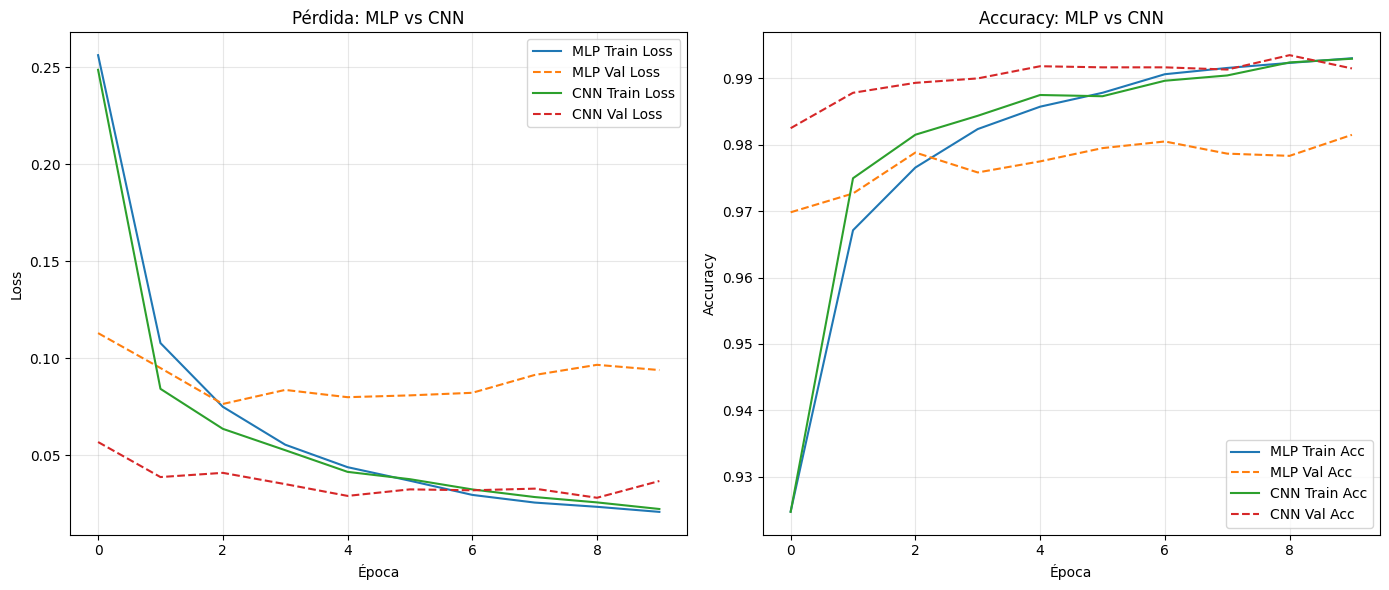

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


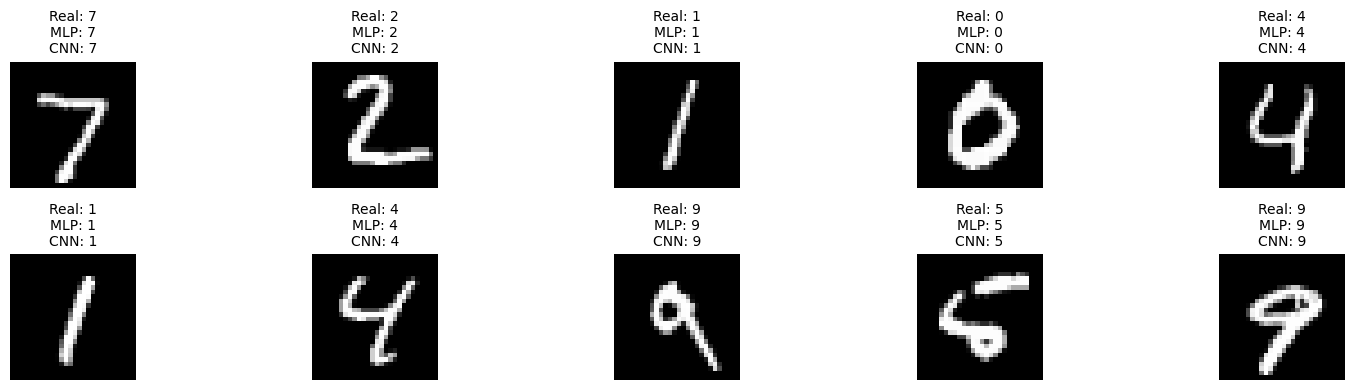

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1. Cargar y preprocesar
# =========================
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalizar a [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Para CNN: añadir canal (28, 28, 1)
x_train_cnn = x_train[..., tf.newaxis]
x_test_cnn = x_test[..., tf.newaxis]

# =========================
# 2. Modelo MLP
# =========================
model_mlp = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Entrenando MLP...")
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=32,
    verbose=1
)

# =========================
# 3. Modelo CNN
# =========================
model_cnn = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation="relu", input_shape=(28, 28, 1)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation="relu"),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation="softmax")
])

model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nEntrenando CNN...")
history_cnn = model_cnn.fit(
    x_train_cnn, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64,
    verbose=1
)

# =========================
# 4. Evaluar en test
# =========================
test_loss_mlp, test_acc_mlp = model_mlp.evaluate(x_test, y_test, verbose=0)
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test, verbose=0)

print(f"\nMLP - Accuracy en test: {test_acc_mlp:.4f}")
print(f"CNN - Accuracy en test: {test_acc_cnn:.4f}")

# =========================
# 5. Gráficas comparativas
# =========================
plt.figure(figsize=(14, 6))

# Pérdida
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history["loss"], label="MLP Train Loss", linestyle="-")
plt.plot(history_mlp.history["val_loss"], label="MLP Val Loss", linestyle="--")
plt.plot(history_cnn.history["loss"], label="CNN Train Loss", linestyle="-")
plt.plot(history_cnn.history["val_loss"], label="CNN Val Loss", linestyle="--")
plt.title("Pérdida: MLP vs CNN")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history_mlp.history["accuracy"], label="MLP Train Acc", linestyle="-")
plt.plot(history_mlp.history["val_accuracy"], label="MLP Val Acc", linestyle="--")
plt.plot(history_cnn.history["accuracy"], label="CNN Train Acc", linestyle="-")
plt.plot(history_cnn.history["val_accuracy"], label="CNN Val Acc", linestyle="--")
plt.title("Accuracy: MLP vs CNN")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================
# 6. Predicciones de ejemplo (opcional)
# =========================
# MLP
preds_mlp = model_mlp.predict(x_test)
pred_labels_mlp = np.argmax(preds_mlp, axis=1)

# CNN
preds_cnn = model_cnn.predict(x_test_cnn)
pred_labels_cnn = np.argmax(preds_cnn, axis=1)

# Mostrar 10 ejemplos con ambas predicciones
plt.figure(figsize=(16, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i], cmap="gray")
    title = (
        f"Real: {y_test[i]}\n"
        f"MLP: {pred_labels_mlp[i]}\n"
        f"CNN: {pred_labels_cnn[i]}"
    )
    plt.title(title, fontsize=10)
    plt.axis("off")
plt.tight_layout()
plt.show()